In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split


from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import accuracy_score, confusion_matrix, precision_score,recall_score,f1_score,classification_report

sns.set_theme(style='whitegrid')

#한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

#마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

1. 주제 및 데이터셋 선택
- 해결하려는 문제
    - 은행 고객의 인적/거래 정보를 바탕으로 이 고객이 향후 은행을 이탈(해지)할지 여부를 예측

문제 유형
- 분류(Classification)
- 타겟 변수: 이탈여부(Exited) (1 = 이탈 , 0 = 유지)
- 이진분류

데이터 출처
- 파일명: Customer-Churn-Records.csv
- Kaggle에 공개된 은행 고객 이탈(Bank Customer Churn) 데이터셋

In [56]:
# 데이터 불러오기
df_origin = pd.read_csv("data\Customer-Churn-Records.csv",index_col=0 ) 
df = df_origin.copy()

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\MoonSungHo\AppData\Local\Temp\ipykernel_13804\3680645272.py:2: SyntaxWarning: invalid escape sequence '\C'
  df_origin = pd.read_csv("data\Customer-Churn-Records.csv",index_col=0 )


In [57]:
df_origin.head()


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
RowNumber,,,,,,,,,,,,,,,,,
1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [58]:

# 컬럼명 한글 매핑
col_map = {
    'RowNumber': '행번호',
    'CustomerId': '고객ID',
    'Surname': '이름(성)',
    'CreditScore': '신용점수',
    'Geography': '국가',
    'Gender': '성별',
    'Age': '나이',
    'Tenure': '거래기간',
    'Balance': '잔액',
    'NumOfProducts': '보유상품수',
    'HasCrCard': '신용카드보유여부',
    'IsActiveMember': '활성회원여부',
    'EstimatedSalary': '추정연봉',
    'Exited': '이탈여부',
    'Complain': '불만접수여부',
    'Satisfaction Score': '만족도점수',
    'Card Type': '카드등급',
    'Point Earned': '적립포인트'
}

df = df_origin.rename(columns=col_map)

df.head()


,고객ID,이름(성),신용점수,국가,성별,나이,거래기간,잔액,보유상품수,신용카드보유여부,활성회원여부,추정연봉,이탈여부,불만접수여부,만족도점수,카드등급,적립포인트
RowNumber,,,,,,,,,,,,,,,,,
1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 1 to 10000
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   고객ID      10000 non-null  int64  
 1   이름(성)     10000 non-null  str    
 2   신용점수      10000 non-null  int64  
 3   국가        10000 non-null  str    
 4   성별        10000 non-null  str    
 5   나이        10000 non-null  int64  
 6   거래기간      10000 non-null  int64  
 7   잔액        10000 non-null  float64
 8   보유상품수     10000 non-null  int64  
 9   신용카드보유여부  10000 non-null  int64  
 10  활성회원여부    10000 non-null  int64  
 11  추정연봉      10000 non-null  float64
 12  이탈여부      10000 non-null  int64  
 13  불만접수여부    10000 non-null  int64  
 14  만족도점수     10000 non-null  int64  
 15  카드등급      10000 non-null  str    
 16  적립포인트     10000 non-null  int64  
dtypes: float64(2), int64(11), str(4)
memory usage: 1.3 MB


결측값 없음

In [60]:
df.describe()

,고객ID,신용점수,나이,거래기간,잔액,보유상품수,신용카드보유여부,활성회원여부,추정연봉,이탈여부,불만접수여부,만족도점수,적립포인트
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [61]:
df.shape

(10000, 17)

## 3. 탐색적 데이터 분석 EDA

### (특성, 타겟) 분포 확인

In [62]:
df['이탈여부'].value_counts()


이탈여부
0    7962
1    2038
Name: count, dtype: int64

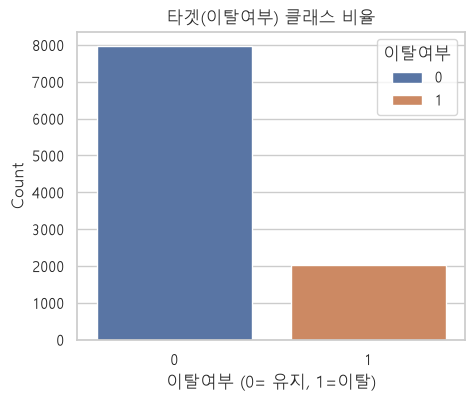

In [63]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='이탈여부', hue= '이탈여부')
plt.title('타겟(이탈여부) 클래스 비율')
plt.xlabel('이탈여부 (0= 유지, 1=이탈)')
plt.ylabel('Count')
plt.show()

타겟이 클래스 불균형 확인 8:2

### (변수간, 변수와 타겟간) 상관관계 분석 및 시각화

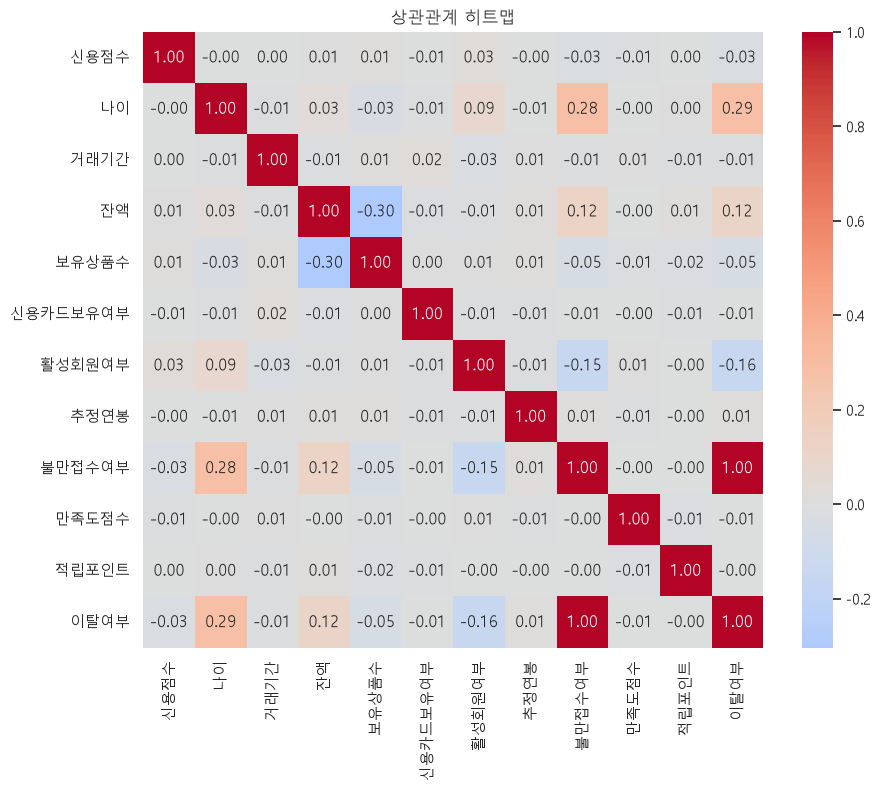

In [64]:

corr_cols = ['신용점수','나이','거래기간','잔액','보유상품수','신용카드보유여부',
             '활성회원여부','추정연봉','불만접수여부','만족도점수',
             '적립포인트','이탈여부']
plt.figure(figsize=(10,8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('상관관계 히트맵')
plt.show()


C:\Users\MoonSungHo\AppData\Local\Temp\ipykernel_13804\3340989815.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')


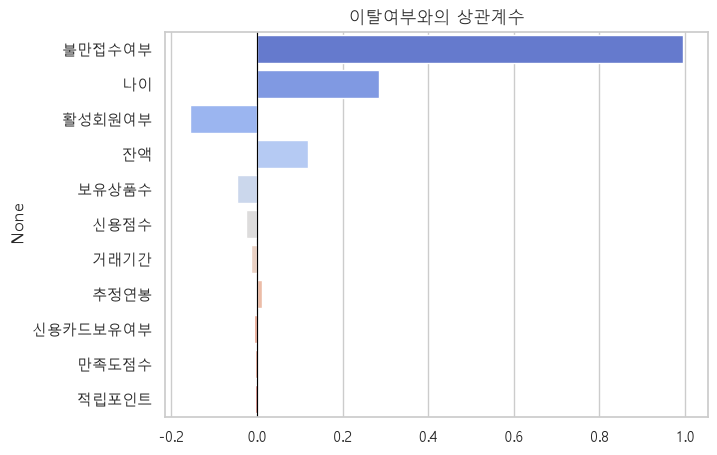

불만접수여부      0.995693
나이          0.285296
활성회원여부     -0.156356
잔액          0.118577
보유상품수      -0.047611
신용점수       -0.026771
거래기간       -0.013656
추정연봉        0.012490
신용카드보유여부   -0.006976
만족도점수      -0.005849
적립포인트      -0.004628
Name: 이탈여부, dtype: float64


In [65]:
target_corr = df[corr_cols].corr()['이탈여부'].drop('이탈여부').sort_values(key=abs, ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.title('이탈여부와의 상관계수')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()
print(target_corr)


불만접수여부가 이탈여부와 거의 1에 가까운 상관관계를 보임.

데이터 누수로 판단되어 전처리 단계에서 불만접수여부 제거

## 4. 데이터 전처리

In [66]:
customer_ids = df['고객ID'].copy()  # 이후 예측 결과와 매칭하기 위해 별도 보관

drop_cols = ['고객ID','이름(성)','불만접수여부']
data = df.drop(columns=drop_cols)
print('제거 후 shape:', data.shape)
data.columns.tolist()

제거 후 shape: (10000, 14)


['신용점수',
 '국가',
 '성별',
 '나이',
 '거래기간',
 '잔액',
 '보유상품수',
 '신용카드보유여부',
 '활성회원여부',
 '추정연봉',
 '이탈여부',
 '만족도점수',
 '카드등급',
 '적립포인트']

이상치 확인

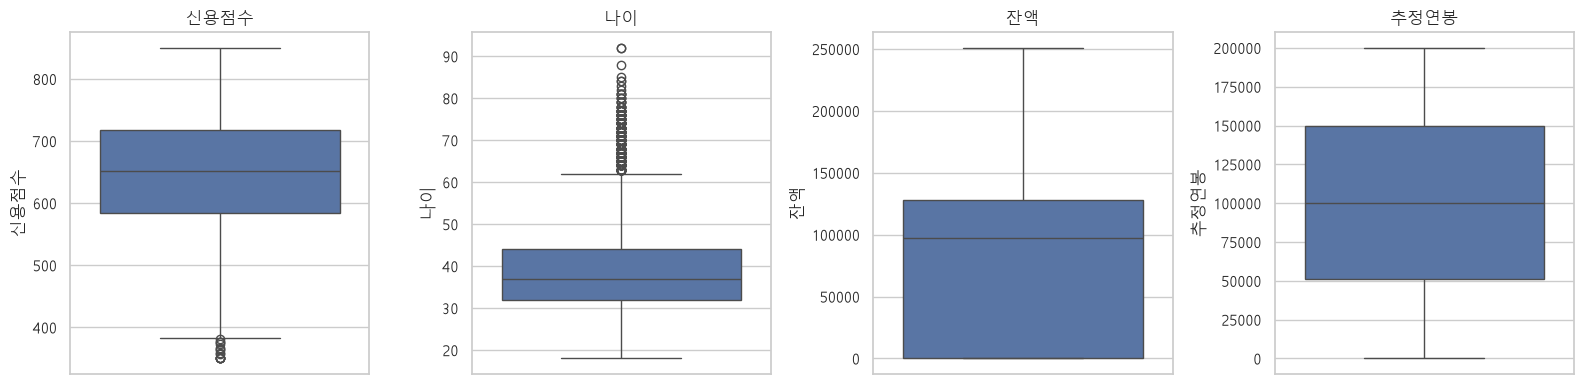

신용점수: IQR 기준 이상치 15개 (0.15%)
나이: IQR 기준 이상치 359개 (3.59%)
잔액: IQR 기준 이상치 0개 (0.00%)
추정연봉: IQR 기준 이상치 0개 (0.00%)


In [67]:
# 이상치 확인 (IQR 기준) - 수치형 컬럼 대상
outlier_check_cols = ['신용점수','나이','잔액','추정연봉']
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, col in zip(axes, outlier_check_cols):
    sns.boxplot(y=data[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

for col in outlier_check_cols:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((data[col] < lower) | (data[col] > upper)).sum()
    print(f'{col}: IQR 기준 이상치 {n_out}개 ({n_out/len(data)*100:.2f}%)')


나이에 이상치가 일부 존재하지만, 실제로 고령 고객이 실존하는 정상적 데이터라고 판단.

### Feature / Target 분리

In [68]:
X = data.drop(columns=['이탈여부'])
y = data['이탈여부']
print('X shape:', X.shape, ' y shape:', y.shape)


X shape: (10000, 13)  y shape: (10000,)


### 범주형 인코딩, 숫자형 스케일링(스케일링은 데이터 분리 후 진행)

- `국가` (프랑스/스페인/독일): 순서가 없는 명목형 → 원-핫 인코딩
- `성별` (남성/여성): 이진 변수 → 0/1 라벨 인코딩
- `카드등급` (실버/골드/플래티넘/다이아몬드): 등급 개념이 있으나 등급과 이탈률 간 뚜렷한
  서열 효과가 EDA에서 보이지 않아 원-핫 인코딩으로 처리

In [71]:
X['성별'] = X['성별'].map({'Male':0, 'Female':1})

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)
print(len(X_train),len(X_test),len(y_train),len(y_test))


8000 2000 8000 2000


In [76]:
df

,고객ID,이름(성),신용점수,국가,성별,나이,거래기간,잔액,보유상품수,신용카드보유여부,활성회원여부,추정연봉,이탈여부,불만접수여부,만족도점수,카드등급,적립포인트
RowNumber,,,,,,,,,,,,,,,,,
1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564


In [ ]:
from sklearn.preprocessing import OneHotEncoder
 
cat_cols = ['국가', '카드등급']
 
onehot = OneHotEncoder(
    drop='first',               # 첫 번째 범주는 제거하여 중복 정보 감소 (모두 0이면 자동으로 나머지가 1)
    handle_unknown='ignore',    # 학습 때 없었던 범주가 나와도 에러 발생하지 않음
    sparse_output=False         # 결과를 일반적인 배열 형태로 변환
)
onehot.fit(X_train[cat_cols])
 
train_cat = pd.DataFrame(
    onehot.transform(X_train[cat_cols]),
    columns=onehot.get_feature_names_out(cat_cols),
    index=X_train.index
)
test_cat = pd.DataFrame(
    onehot.transform(X_test[cat_cols]),
    columns=onehot.get_feature_names_out(cat_cols),
    index=X_test.index
)
 
X_train = pd.concat([X_train.drop(columns=cat_cols), train_cat], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_cols), test_cat], axis=1)
 
print('X_train:', X_train.shape, ' X_test:', X_test.shape)
X_train.head()

X_train: (8000, 16)  X_test: (2000, 16)


,신용점수,성별,나이,거래기간,잔액,보유상품수,신용카드보유여부,활성회원여부,추정연봉,만족도점수,적립포인트,국가_Germany,국가_Spain,카드등급_GOLD,카드등급_PLATINUM,카드등급_SILVER
RowNumber,,,,,,,,,,,,,,,,
3524,835,0,35,6,127120.07,1,1,0,28707.69,2,525,0.0,0.0,0.0,1.0,0.0
3101,810,0,35,3,96814.46,2,1,1,120511.03,1,275,1.0,0.0,1.0,0.0,0.0
1152,826,1,29,4,129938.07,1,0,1,190200.53,1,708,0.0,1.0,1.0,0.0,0.0
9332,605,0,19,8,166133.28,1,1,1,107994.99,5,870,1.0,0.0,0.0,0.0,0.0
8106,659,0,60,2,0.00,1,1,0,177480.45,2,365,0.0,1.0,1.0,0.0,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler
 
scale_cols = ['신용점수','나이','잔액','추정연봉','적립포인트']
 
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])
 
X_train_scaled.head()

,신용점수,성별,나이,거래기간,잔액,보유상품수,신용카드보유여부,활성회원여부,추정연봉,만족도점수,적립포인트,국가_Germany,국가_Spain,카드등급_GOLD,카드등급_PLATINUM,카드등급_SILVER
RowNumber,,,,,,,,,,,,,,,,
3524,1.914977,0,-0.374756,6,0.811906,1,1,0,-1.241451,2,-0.357796,0.0,0.0,0.0,1.0,0.0
3101,1.655657,0,-0.374756,3,0.325656,2,1,1,0.357288,1,-1.467942,1.0,0.0,1.0,0.0,0.0
1152,1.821622,1,-0.944511,4,0.857120,1,0,1,1.570920,1,0.454831,0.0,1.0,1.0,0.0,0.0
9332,-0.470765,0,-1.894103,8,1.437868,1,1,1,0.139324,5,1.174205,1.0,0.0,0.0,0.0,0.0
8106,0.089366,0,1.999223,2,-1.227721,1,1,0,1.349401,2,-1.068290,0.0,1.0,1.0,0.0,0.0


## 5. 모델 학습

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f'{name} 학습 완료')


Logistic Regression 학습 완료
Random Forest 학습 완료
Gradient Boosting 학습 완료


## 6. 모델 평가 및 시각화, 결과 해석

In [80]:

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

results = []
preds_dict = {}
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    preds_dict[name] = y_pred
    y_proba = model.predict_proba(X_test_scaled)[:,1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.7100,0.3847,0.7034,0.4974
Random Forest,0.8535,0.6420,0.6373,0.6396
Gradient Boosting,0.8750,0.7862,0.5319,0.6345


### Confusion Matrix

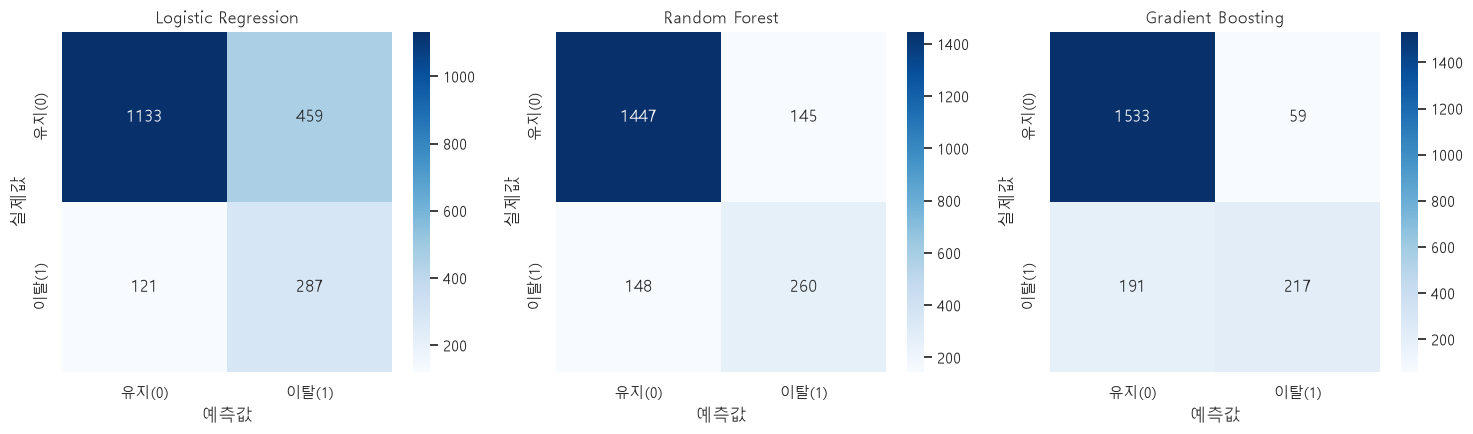

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
for ax, (name, y_pred) in zip(axes, preds_dict.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['유지(0)','이탈(1)'], yticklabels=['유지(0)','이탈(1)'])
    ax.set_title(name)
    ax.set_xlabel('예측값')
    ax.set_ylabel('실제값')
plt.tight_layout()
plt.show()

### Classification Report

In [82]:
for name, y_pred in preds_dict.items():
    print(f'===== {name} =====')
    print(classification_report(y_test, y_pred, target_names=['유지(0)','이탈(1)']))


===== Logistic Regression =====
              precision    recall  f1-score   support

       유지(0)       0.90      0.71      0.80      1592
       이탈(1)       0.38      0.70      0.50       408

    accuracy                           0.71      2000
   macro avg       0.64      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

===== Random Forest =====
              precision    recall  f1-score   support

       유지(0)       0.91      0.91      0.91      1592
       이탈(1)       0.64      0.64      0.64       408

    accuracy                           0.85      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000

===== Gradient Boosting =====
              precision    recall  f1-score   support

       유지(0)       0.89      0.96      0.92      1592
       이탈(1)       0.79      0.53      0.63       408

    accuracy                           0.88      2000
   macro avg       0.84      0.75      0

## 결과 해석

1. Logistic Regression
    - Accuracy : 0.710
    - Precision : 0.385
    - Recall : 0.703
    - F1-score : 0.497

    - 재현율(Recall)이 0.7 정도로 가장 높다. 실제 이탈 고객의 약 70%를 찾아냈다.  
    하지만 정밀도(Precision)가 0.385로 매우 낮다.(이탈이라고 예측한 고객중 실제 이탈고객은 38.5%)
- 결론 : 로지스틱회귀분석은 이탈 고객을 놓치는 비율은 적지만, 불필요한 고객 관리 비용이 많이 발생할 수 있는 모델이다.

2. Random Forest
    - Accuracy : 0.854
    - Precision : 0.642
    - Recall : 0.637
    - F1-score : 0.640

    - 정확도(Accuracy) 가 크게 향상되었다. 
    - Precision과 Recall이 모두 약 64% 수준으로 균형을 이루었다.
    - F1-score가 가장 높다(0.640)
- 결론 : 이탈 고객 탐지와 오탐(FT) 사이의 균이 가장 좋은 모델.  
        가장 안정적인 성능을 보인다

3. Gradient Boosting
    - Accuracy : 0.875
    - Precision : 0.786
    - Recall : 0.532
    - F1-score : 0.635

    - 정확도(Accuracy) 가 가장높다. 
    - 정밀도(Precision) 도 가장 높다. (이탈이라고 예측한 고객의 약 79%가 실제 이탈 고객이다.)
    - 하지만 재현율(Recall)이 가장 낮다.(실제 이탈 고객의 약 절반 정도만 찾아냈다.)
- 결론 : 예측은 신중하지만 실제 이탈 고객을 많이 놓치는 모델이다.